# Phytclust Workflow

In [1]:
from phytclust import PhytClust
from phytclust import plot_tree
from phytclust import pairwise_distances
import io
import os
from Bio import Phylo

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
results_dir = "/home/ganesank/project/phytclust/results"  # change

## Importing 

In [2]:
# With newick string
tree_string = "((((((((((((((A:1,B:1):1,C:1):1,D:1):1,E:1):3,F:1):1,G:1):1,H:1):1,I:1):1,J:1):1,K:1):1,L:1):1,M:1):1,N:1):1,O:1);"
# tree_string = "(OTR_human:0.3811057684,((OTR_chicken:0.0916417601,OTR_zebra_finch:0.2185888587)100:0.2038413592,(((OTR_wall_lizard:0.4020158148,(OTRb_zebrafish:0.2425260961,OTR_snake:0.4756226684)99:0.0818685058)100:0.2114707415,OTR_sea_turtle:0.4763870751)96:0.0957011482,((OTR_coelacanth:0.6487930020,((OTR_white_shark:0.3052001022,OTR_elephant_shark:0.3583541759)100:0.2168099597,(((((OTRa_clingfish:0.4203590544,(OTRa_zebrafish:0.2490518077,OTRa_eel:0.3377224960)100:0.2753551378)96:0.0751505407,OTRb_clingfish:0.5833534164)96:0.0639574775,(OTRb_eel:0.4751064450,OTR_spotted_gar:0.6065898938)96:0.1899103149)100:0.1111385650,(OTRa_piranha:0.4868642088,OTRb_piranha:0.5264311912)99:0.1559409589)69:0.0795794071,((((((V1Ab_piranha:0.8412031944,((V1Aa_zebrafish:0.3398284257,(V1Ab_zebrafish:0.2799920970,V1Ab_eel_exons:0.3652421656)100:0.1220260378)43:0.0492126453,(V1Aa_piranha:0.3564081277,V1Ab_clingfish:0.6053809714)53:0.0984397834)35:0.0180372180)48:0.0642140480,(V1Aa_clingfish:0.4224847894,(V1A_spotted_gar:0.5758225095,V1Aa_eel:0.7336201524)85:0.1375352011)76:0.0575276083)59:0.0802958547,(((V1A_human:0.5042827761,V1A_mouse:0.3767685558)100:0.2835137463,(((V1A_chicken:0.0796965655,V1A_zebra_finch:0.1540645581)100:0.1486805660,V1A_sea_turtle:0.1984452381)100:0.1040327116,(V1A_snake:0.2405625135,V1A_wall_lizard:0.1793105264)100:0.1871880929)100:0.1662101683)80:0.1036814609,(V1A_coelacanth:0.7929578303,V1A_frog:0.5409560521)54:0.1181536606)49:0.0560082713)41:0.0433069099,(V1A_elephant_shark:0.2959256193,V1A_white_shark:0.3033017072)100:0.4168409826)100:0.1970914675,(((V1B_coelacanth:0.5963023570,V1B_frog:0.8365014003)100:0.2519501060,((V1B_human:0.2849807425,V1B_mouse:0.2554161440)100:0.3508933367,((V1B_chicken:0.2765002817,V1B_zebra_finch:0.1421412715)100:0.0789781323,(V1B_sea_turtle:0.2180187648,(V1B_snake:0.3551038101,V1B_wall_lizard:0.1621107193)100:0.3079183415)95:0.0682930767)100:0.1998778770)100:0.3111257471)93:0.0448360566,V1B_elephant_shark:0.7455178498)100:0.1670559949)69:0.0538484962,(((OTRb_sea_lamprey:0.4510998010,OTRa_sea_lamprey:0.6538178312)93:0.1394533428,V1A_sea_lamprey:0.8075923630)100:0.1566192672,((((((((((V2A_chicken:0.1532023667,V2A_zebra_finch:0.1621898922)100:0.1417457584,V2A_sea_turtle:0.1704960516)100:0.1156101565,V2A_wall_lizard:0.4868537300)96:0.1049379690,V2A_frog:0.4410915959)100:0.2974804520,V2A_spotted_gar:0.7431509714)90:0.0983058927,V2A_elephant_shark:0.7814533780)100:0.2174467895,(((V2Aa_clingfish:0.5159503312,(V2Ab_zebrafish:0.1987597544,V2Ab_eel:0.4902344054)100:0.1846022384)100:0.4268637000,V2A_white_shark:0.8753997160)100:0.3599345416,(V2A_sea_lamprey:0.6539787252,V2B_sea_lamprey:0.6345402785)100:0.2005935268)96:0.0630700335)80:0.0586936512,((((V2B_spotted_gar:0.3307554119,V2B_coelacanth:0.6349068308)100:0.3165071250,V2Bb_clingfish:0.6040122628)85:0.0844661640,(V2Ba_zebrafish:0.5377089887,V2Ba_eel:0.6272980925)99:0.1901505764)73:0.0754084983,V2Ba_piranha:0.8420406172)99:0.1637381980)99:0.0570266363,((((((V2Ca_clingfish:0.4234248640,(V2Ca_piranha:0.2130525343,V2Ca_eel:0.2509524006)100:0.1682671516)100:0.2219925264,(V2Ca_zebrafish:0.5501446265,V2Cb_zebrafish:0.4115219692)100:0.2576704132)85:0.0447310010,(V2Cb_eel:0.3214308432,V2Cb_piranha:0.4039247614)100:0.1590777762)90:0.0579946381,V2Cb_clingfish:0.8729593664)100:0.1240954705,V2C_spotted_gar:0.6389245150)100:0.1124388084,((V2C_coelacanth:0.7679474287,V2C_frog:0.9384819782)100:0.1979732140,((V2C_human:0.1841739071,V2C_mouse:0.2291934765)100:0.5693781274,(V2C_snake:0.4415458036,V2C_wall_lizard:0.1911136079)100:0.4066214128)100:0.2459094149)88:0.1026255535)100:0.0850760643)100:0.1737908752,VTR_amphioxus:1.2441336033)100:0.1298219970)90:0.0643757942)100:0.2903200976)91:0.1015111059)99:0.0383743724)77:0.0446380009,OTR_frog:0.5627284467)96:0.0762360515)93:0.0788884192)100:0.3130418141,OTR_mouse:0.4728687496);"
tree_string = "(((A:5, B:3)C1:6, (C:3, D:7)D1:4)A13:22, (((E:7, F:13)E1:5, G:6)E12:10, H:60)B:35):1;"

tree = Phylo.read(io.StringIO(tree_string), "newick")\
    
# With newick file
tree_path = "../output_tree.nwk"

tree = Phylo.read(tree_path, "newick", rooted=True)

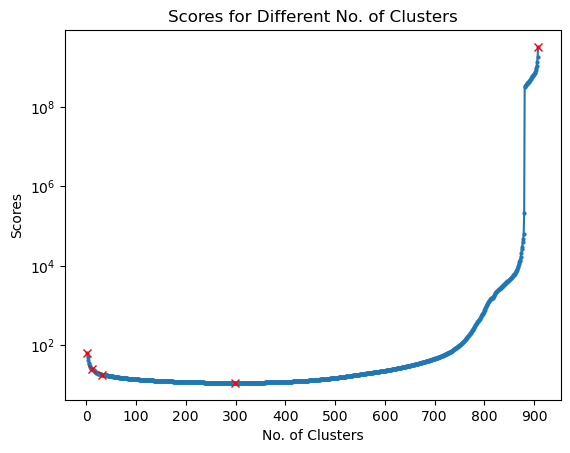

Found only 5 peak(s)


In [3]:
clust_obj = PhytClust(
    tree,
    plot_scores=True,
    num_peaks=100,
    outgroup=None)

In [ ]:

clust_obj.plot(n = 24,
    width_scale=2,
    height_scale=0.3,
    show_branch_lengths=False,
    hide_internal_nodes=True,
    outlier=False,
    marker_size=50,
    # save=True,
    # results_dir=results_dir,
)

In [ ]:
# plot with labels
import matplotlib.pyplot as plt 
plt.rcParams.update({"font.size": 8})

label_func = lambda x: x.name if hasattr(x, "name") else x

clust_obj.plot(
    save=True,
    results_dir="../results",  # results_dir
    show_terminal_labels=True,
    outlier=False,
    top_n=1,
    label_func=label_func,
    width_scale=8,
    height_scale=0.4,
    marker_size=40,
)

In [ ]:
# plot for all k values
for n in range(1, len(tree.get_terminals())):
    clust_obj.plot(
        n=n,
        height_scale=0.4,
        outlier=False,
        save=False,
        results_dir="../results",
    )